# Welcome to Colab!

In [21]:

!pip install pyspark

#Airline Delay Analysis using PySpark

In [22]:

import pyspark
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("Tutorial1_CN7030") \
                            .master("local[*]")\
                            .config("spark.some.config.option", "some-value") \
                            .getOrCreate()

In [23]:
import os

print(os.getcwd())
print(os.listdir('/content'))

/content
['.config', 'Airline_Delay_Cause.csv', 'sample_data']


In [24]:
!find / -name "Airline_Delay_Cause.csv" 2>/dev/null

/content/Airline_Delay_Cause.csv


#Dataset Loading

In [25]:
from pyspark.sql import functions as F

df = spark.read.csv(
    "/content/Airline_Delay_Cause.csv",
    header=True,
    inferSchema=True
)

print("Rows:", df.count())
print("Columns:", len(df.columns))

df.printSchema()
df.show(5)

Rows: 398233
Columns: 21
root
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- carrier: string (nullable = true)
 |-- carrier_name: string (nullable = true)
 |-- airport: string (nullable = true)
 |-- airport_name: string (nullable = true)
 |-- arr_flights: integer (nullable = true)
 |-- arr_del15: integer (nullable = true)
 |-- carrier_ct: double (nullable = true)
 |-- weather_ct: double (nullable = true)
 |-- nas_ct: double (nullable = true)
 |-- security_ct: double (nullable = true)
 |-- late_aircraft_ct: double (nullable = true)
 |-- arr_cancelled: integer (nullable = true)
 |-- arr_diverted: integer (nullable = true)
 |-- arr_delay: integer (nullable = true)
 |-- carrier_delay: integer (nullable = true)
 |-- weather_delay: integer (nullable = true)
 |-- nas_delay: integer (nullable = true)
 |-- security_delay: integer (nullable = true)
 |-- late_aircraft_delay: integer (nullable = true)

+----+-----+-------+-------------+-------+--------------------+

### Null Value Check

In [26]:
null_counts = df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df.columns
])

null_counts.show()

+----+-----+-------+------------+-------+------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|year|month|carrier|carrier_name|airport|airport_name|arr_flights|arr_del15|carrier_ct|weather_ct|nas_ct|security_ct|late_aircraft_ct|arr_cancelled|arr_diverted|arr_delay|carrier_delay|weather_delay|nas_delay|security_delay|late_aircraft_delay|
+----+-----+-------+------------+-------+------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|   0|    0|      0|           0|      0|           0|        657|      950|       657|       657|   657|        657|             657|          657|         657|      657|          657|          657|      657|           657|                657|
+----+-----+-------+

### Missing Value Imputation

In [27]:
numeric_cols = [
    'arr_flights',
    'arr_del15',
    'carrier_ct',
    'weather_ct',
    'nas_ct',
    'security_ct',
    'late_aircraft_ct'
]

df = df.fillna(0, subset=numeric_cols)

### Outlier Handling

In [28]:
df = df.filter(F.col("arr_flights") > 0)

df = df.filter(
    F.col("arr_del15") <= F.col("arr_flights")
)

print("Rows after cleaning:", df.count())

Rows after cleaning: 397576


## Question 1
### How have overall flight delays changed over time?

### Interpretation

The delay rate fluctuates over time, indicating periods of higher and lower operational performance.

In [29]:
delay_time = (
    df.groupBy("year", "month")
      .agg(
          F.sum("arr_del15").alias("total_delays"),
          F.sum("arr_flights").alias("total_flights")
      )
      .withColumn(
          "delay_rate",
          F.col("total_delays") / F.col("total_flights")
      )
      .orderBy("year", "month")
)

delay_time.show()

+----+-----+------------+-------------+-------------------+
|year|month|total_delays|total_flights|         delay_rate|
+----+-----+------------+-------------+-------------------+
|2003|    6|       89441|       536496|0.16671326533655423|
|2003|    7|      104579|       558568| 0.1872269804213632|
|2003|    8|      106326|       556984|0.19089596828634214|
|2003|    9|       67386|       527714|0.12769416767415684|
|2003|   10|       69394|       552370|0.12562955989644622|
|2003|   11|       96177|       528171|0.18209443532492317|
|2003|   12|      120668|       555495|0.21722607764246302|
|2004|    1|      128236|       583987| 0.2195870798493802|
|2004|    2|      114517|       553876|0.20675566372256607|
|2004|    3|      104031|       601412|0.17297792528250183|
|2004|    4|       93754|       582970| 0.1608213115597715|
|2004|    5|      121019|       594457|0.20357906459171984|
|2004|    6|      148726|       588792|0.25259514395576027|
|2004|    7|      135999|       614166| 

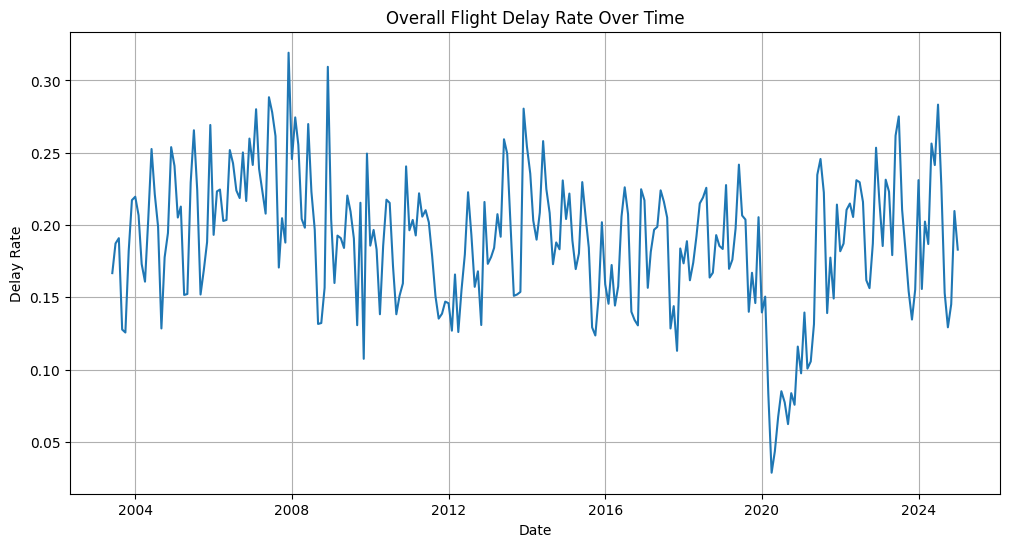

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

pdf = delay_time.toPandas()

pdf["date"] = pd.to_datetime(
    pdf["year"].astype(str) + "-" +
    pdf["month"].astype(str)
)

plt.figure(figsize=(12,6))
plt.plot(pdf["date"], pdf["delay_rate"])

plt.title("Overall Flight Delay Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Delay Rate")

plt.grid(True)
plt.show()

## Question 2
### Which airlines have the highest percentage of delayed flights?

In [31]:
carrier_delay_rate = (
    df.groupBy("carrier_name")
      .agg(
          F.sum("arr_del15").alias("delays"),
          F.sum("arr_flights").alias("flights")
      )
      .withColumn(
          "delay_rate",
          F.col("delays") / F.col("flights")
      )
      .orderBy(F.desc("delay_rate"))
)

carrier_delay_rate.show()

+--------------------+-------+-------+-------------------+
|        carrier_name| delays|flights|         delay_rate|
+--------------------+-------+-------+-------------------+
|Peninsula Airways...|   1015|   3227|0.31453362255965295|
|   Frontier Airlines| 272946|1041066| 0.2621793430964031|
|Trans States Airl...|  43815| 178098|0.24601623825085064|
|Atlantic Southeas...| 618201|2526762|0.24466134918919946|
|     JetBlue Airways|1151344|4720734|0.24389088645960563|
|Commutair Aka Cha...|  68214| 280544|0.24314902475191058|
|       Allegiant Air| 184022| 774867|0.23748849802611288|
|    Spirit Air Lines|  97462| 412396|0.23633109923471615|
|         Comair Inc.| 394146|1765828|0.22320746981019668|
|Northwest Airline...| 610029|2767549|0.22042211357414088|
|Continental Air L...| 537252|2447164|0.21954066012739645|
|American Eagle Ai...|1129165|5184465| 0.2177977862711003|
|Frontier Airlines...| 241699|1120723|0.21566346010566392|
|ExpressJet Airlin...|1536141|7148719|0.2148833937940489

### Interpretation

The chart compares the delay rates of different airlines. Airlines with higher delay rates experience a greater proportion of delayed flights compared to airlines with lower delay rates.

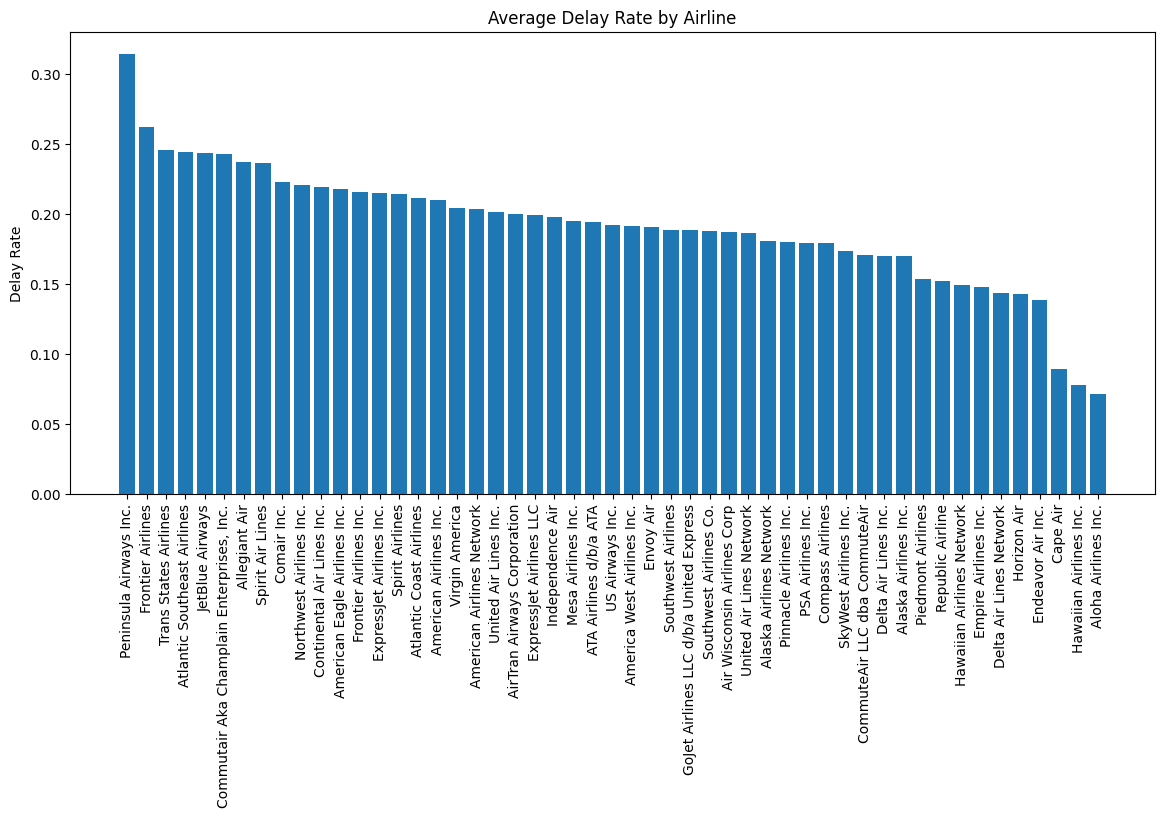

In [32]:
pdf = carrier_delay_rate.toPandas()

plt.figure(figsize=(14,6))
plt.bar(pdf["carrier_name"], pdf["delay_rate"])

plt.xticks(rotation=90)

plt.title("Average Delay Rate by Airline")
plt.ylabel("Delay Rate")

plt.show()

## Question 3
### Which airlines experience the most carrier-caused delays?

In [33]:
carrier_caused = (
    df.groupBy("carrier_name")
      .agg(
          F.sum("carrier_ct").alias("carrier_delays")
      )
      .orderBy(F.desc("carrier_delays"))
)

carrier_caused.show()

+--------------------+------------------+
|        carrier_name|    carrier_delays|
+--------------------+------------------+
|SkyWest Airlines ...| 873465.6399999987|
|Southwest Airline...| 862382.4499999996|
|  Southwest Airlines| 572138.8499999996|
|American Airlines...| 557837.3600000013|
|Delta Air Lines Inc.| 486205.5400000016|
|American Airlines...| 394088.7200000002|
|United Air Lines ...| 383910.7000000003|
|ExpressJet Airlin...| 370796.6800000004|
|     JetBlue Airways| 362771.3800000007|
|Delta Air Lines N...|338247.55999999994|
|American Eagle Ai...|280421.53999999946|
|     US Airways Inc.|272573.00999999966|
|United Air Lines ...| 228146.0799999994|
|Atlantic Southeas...|218409.84999999977|
|  Mesa Airlines Inc.|212565.42000000004|
|Northwest Airline...|198141.91999999929|
|         Comair Inc.|146193.59000000003|
|Alaska Airlines Inc.|113977.73999999992|
|Continental Air L...|112686.42999999982|
|           Envoy Air|108344.07999999973|
+--------------------+------------

### Interpretation

Carrier-caused delays are delays resulting from airline operations such as maintenance issues, crew scheduling, and baggage handling. The chart highlights airlines with the highest number of such delays.

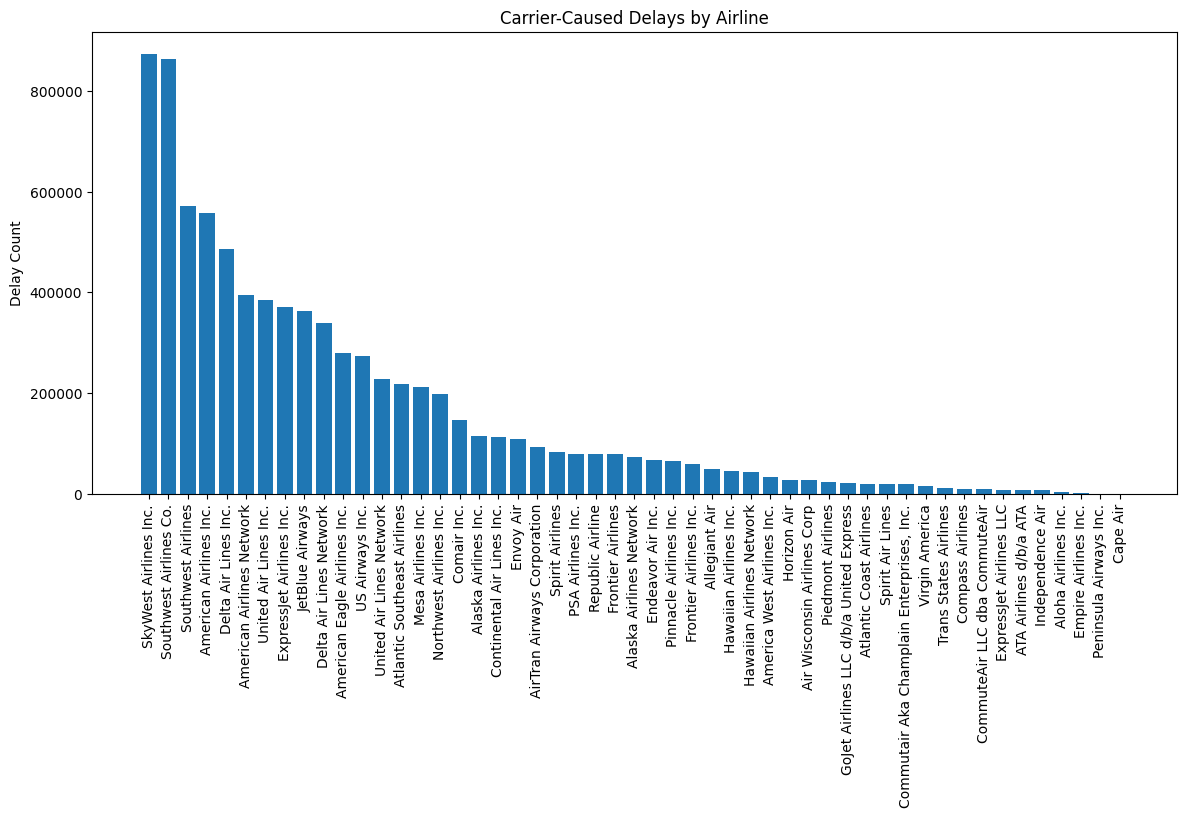

In [34]:
pdf = carrier_caused.toPandas()

plt.figure(figsize=(14,6))
plt.bar(pdf["carrier_name"], pdf["carrier_delays"])

plt.xticks(rotation=90)

plt.title("Carrier-Caused Delays by Airline")
plt.ylabel("Delay Count")

plt.show()

## Question 4
### Which airports have the highest delay rates?

In [35]:
airport_delay = (
    df.groupBy("airport")
      .agg(
          F.sum("arr_del15").alias("delays"),
          F.sum("arr_flights").alias("flights")
      )
      .withColumn(
          "delay_rate",
          F.col("delays") / F.col("flights")
      )
      .orderBy(F.desc("delay_rate"))
)

airport_delay.show()

+-------+------+-------+-------------------+
|airport|delays|flights|         delay_rate|
+-------+------+-------+-------------------+
|    YNG|     2|      2|                1.0|
|    SOP|   133|    317| 0.4195583596214511|
|    DUT|   770|   2074| 0.3712632594021215|
|    FOE|   164|    449|0.36525612472160357|
|    CDB|    90|    262| 0.3435114503816794|
|    ILG|   688|   2121| 0.3243752946723244|
|    SLE|   281|    880|0.31931818181818183|
|    MCN|  2050|   6483|0.31621163041801637|
|    BQN|  9692|  33747| 0.2871958988947166|
|    PQI|  1078|   3780| 0.2851851851851852|
|    OTH|  2698|   9572|0.28186376932720436|
|    PGD| 11681|  41723| 0.2799654866620329|
|    ISO|   407|   1456|0.27953296703296704|
|    APF|   674|   2418| 0.2787427626137304|
|    PSE|  4042|  14740|0.27421981004070556|
|    PVU|  2366|   8666| 0.2730210016155089|
|    EWR|776477|2848697| 0.2725726884958281|
|    SFB| 18249|  67628| 0.2698438516590761|
|    PFN|  6244|  23422| 0.2665869695158398|
|    CEC| 

### Interpretation

The chart identifies airports with the highest delay rates. Airports with higher delay percentages may experience congestion, adverse weather conditions, or operational challenges.

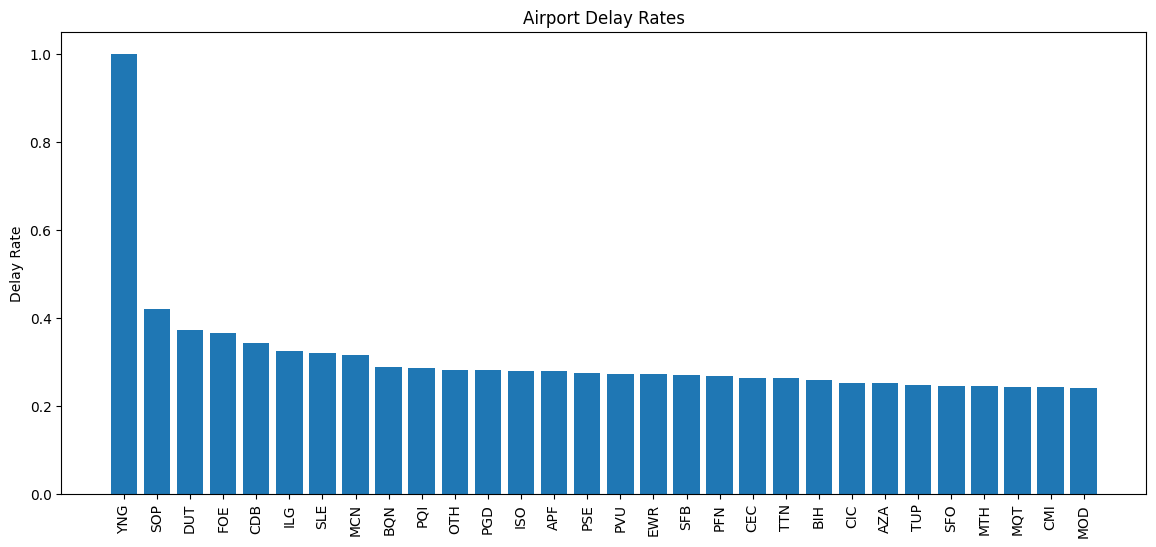

In [36]:
pdf = airport_delay.limit(30).toPandas()

plt.figure(figsize=(14,6))
plt.bar(pdf["airport"], pdf["delay_rate"])

plt.xticks(rotation=90)

plt.title("Airport Delay Rates")
plt.ylabel("Delay Rate")

plt.show()

## Question 5
### What are the dominant causes of delays across all flights?

In [37]:
yearly_causes = (
    df.groupBy("year")
      .agg(
          F.sum("carrier_ct").alias("carrier"),
          F.sum("weather_ct").alias("weather"),
          F.sum("nas_ct").alias("nas"),
          F.sum("security_ct").alias("security"),
          F.sum("late_aircraft_ct").alias("late_aircraft")
      )
      .orderBy("year")
)

yearly_causes.show()

+----+------------------+------------------+------------------+------------------+------------------+
|year|           carrier|           weather|               nas|          security|     late_aircraft|
+----+------------------+------------------+------------------+------------------+------------------+
|2003|164663.44999999992|26807.649999999947| 281803.4000000005|2189.2999999999984|178507.31000000026|
|2004| 363577.4500000017| 71606.14000000026| 561139.1199999994| 4648.730000000007|420421.50000000006|
|2005| 413227.0199999995| 66681.77999999984| 539380.8100000045| 3785.939999999994|442989.78999999893|
|2006| 457816.6699999997|  66538.1499999999| 556312.9000000024| 5903.730000000009| 528966.0600000013|
|2007| 520596.5899999985| 72306.87999999995| 598257.7999999961| 4939.479999999995| 607928.2500000012|
|2008|411600.85999999975| 56639.44000000007| 549861.1200000002|           3254.29| 503380.7199999952|
|2009|323742.69999999925| 41865.17000000006|450644.75000000047| 2327.930000000003|

### Interpretation

The stacked bar chart shows the contribution of different delay causes over time. Carrier delays and late aircraft delays often account for a large proportion of overall delays.

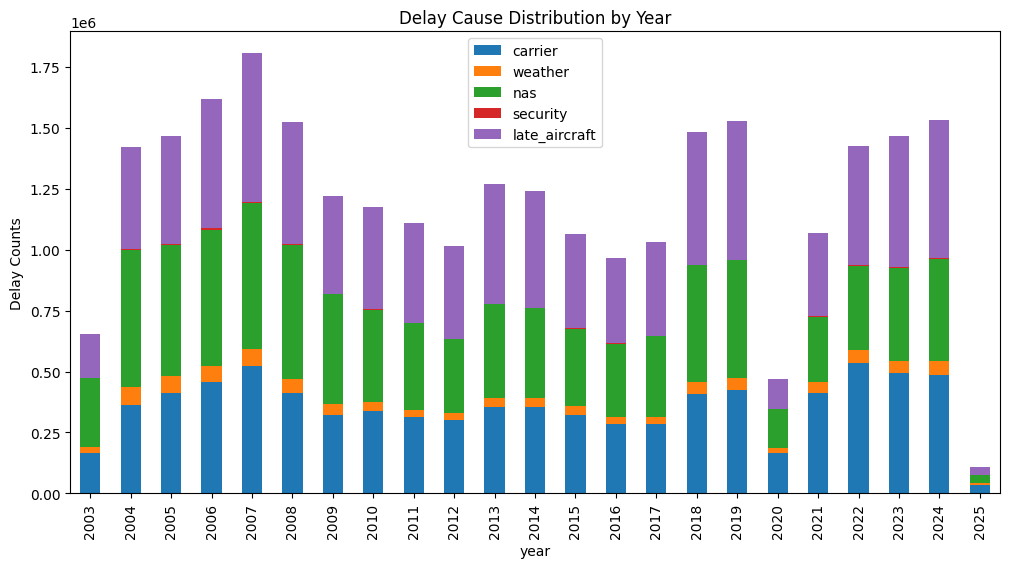

In [38]:
pdf = yearly_causes.toPandas()

pdf.set_index("year").plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Delay Cause Distribution by Year")
plt.ylabel("Delay Counts")

plt.show()

## Question 6
### How do causes vary by season?

In [39]:
monthly_causes = (
    df.groupBy("month")
      .agg(
          F.sum("carrier_ct").alias("carrier"),
          F.sum("weather_ct").alias("weather"),
          F.sum("nas_ct").alias("nas"),
          F.sum("security_ct").alias("security"),
          F.sum("late_aircraft_ct").alias("late_aircraft")
      )
      .orderBy("month")
)

monthly_causes.show()

+-----+-----------------+------------------+-----------------+------------------+------------------+
|month|          carrier|           weather|              nas|          security|     late_aircraft|
+-----+-----------------+------------------+-----------------+------------------+------------------+
|    1|695229.3900000013|101214.84000000013|775301.3099999991|            5874.9| 776527.4600000014|
|    2|        587378.56| 80368.43999999994|697369.4699999995|4636.6900000000005| 686051.4100000008|
|    3| 668602.830000001| 65666.41999999998|736361.5999999982| 5840.680000000004|  795935.029999996|
|    4|592979.5999999979| 60836.24000000002|657975.9999999999| 4879.580000000004| 704912.0799999987|
|    5|629577.3299999969| 80206.46000000022| 712884.390000003| 4626.129999999997| 765547.8499999988|
|    6|829000.2700000001| 119398.0199999997|857503.5099999984|6664.2100000000055|1032488.4200000023|
|    7|873918.7600000019|125390.75999999963|854304.5999999992| 6770.660000000001|1079751.23

### Interpretation

Seasonal trends can be observed across different delay causes. Weather-related delays may increase during winter months, while late-aircraft delays may rise during busy travel seasons.

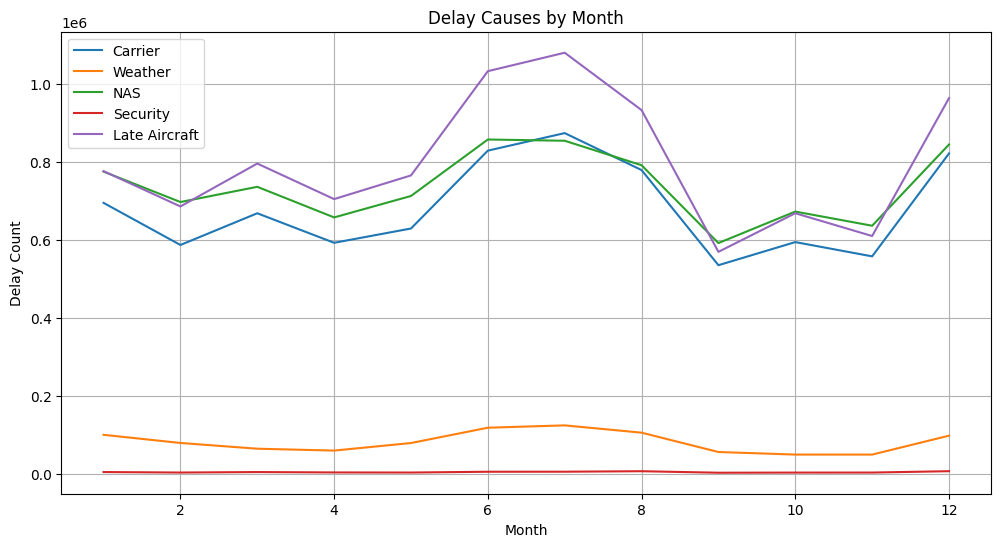

In [40]:
pdf = monthly_causes.toPandas()

plt.figure(figsize=(12,6))

plt.plot(pdf["month"], pdf["carrier"], label="Carrier")
plt.plot(pdf["month"], pdf["weather"], label="Weather")
plt.plot(pdf["month"], pdf["nas"], label="NAS")
plt.plot(pdf["month"], pdf["security"], label="Security")
plt.plot(pdf["month"], pdf["late_aircraft"], label="Late Aircraft")

plt.legend()

plt.title("Delay Causes by Month")
plt.xlabel("Month")
plt.ylabel("Delay Count")

plt.grid(True)

plt.show()

## Question 7
### Which months have the highest and lowest delay percentages?

In [41]:
month_delay = (
    df.groupBy("month")
      .agg(
          F.sum("arr_del15").alias("delays"),
          F.sum("arr_flights").alias("flights")
      )
      .withColumn(
          "delay_rate",
          F.col("delays") / F.col("flights")
      )
      .orderBy("month")
)

month_delay.show()

+-----+-------+--------+-------------------+
|month| delays| flights|         delay_rate|
+-----+-------+--------+-------------------+
|    1|2354148|11988521| 0.1963668412475567|
|    2|2055802|10553304|0.19480174171046338|
|    3|2272405|12121573|0.18746783111399815|
|    4|2021582|11409296|0.17718726904797633|
|    5|2192840|11636972|0.18843733576053978|
|    6|2845053|12331062| 0.2307224633206775|
|    7|2940136|12907171| 0.2277908923651821|
|    8|2618484|12850510|0.20376498675928037|
|    9|1759080|11804903|0.14901266024803422|
|   10|1991538|12335061|0.16145343748198732|
|   11|1860435|11770852|0.15805440421814834|
|   12|2736989|12079517| 0.2265809965746147|
+-----+-------+--------+-------------------+



### Interpretation

The chart reveals how delay percentages vary throughout the year. Months with higher delay rates may be influenced by weather conditions, increased travel demand, or holiday-related congestion.

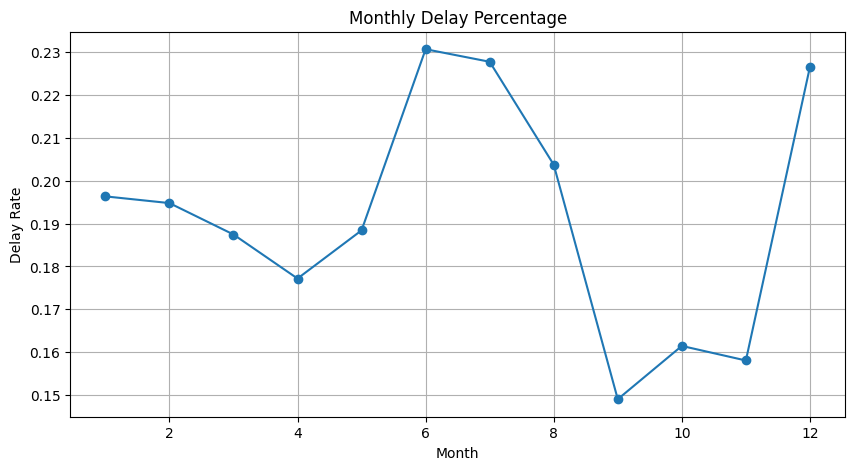

In [42]:
pdf = month_delay.toPandas()

plt.figure(figsize=(10,5))

plt.plot(
    pdf["month"],
    pdf["delay_rate"],
    marker="o"
)

plt.title("Monthly Delay Percentage")
plt.xlabel("Month")
plt.ylabel("Delay Rate")

plt.grid(True)

plt.show()

## Conclusion

This analysis used PySpark to explore airline delay patterns and their causes. The results highlighted differences in airline performance, airport delay rates, seasonal trends, and major delay causes. Spark DataFrame operations enabled efficient processing and analysis of large-scale airline delay data.